
Best-Case, Already Sorted Arrays:

Execution time on 5 elements   =  0.600999987909745 

Execution time on 10 elements   =  0.44830001115769846 

Execution time on 11 elements   =  0.19359999896551017 

Execution time on 20 elements   =  0.28140000267740106 


Worst-Case, Reverse Sorted Arrays:

Execution time on 5 elements   =  7.558199990853609 

Execution time on 10 elements   =  239910.020100001 

Execution time on 11 elements   =  2922713.6711999946 


Generating plot...


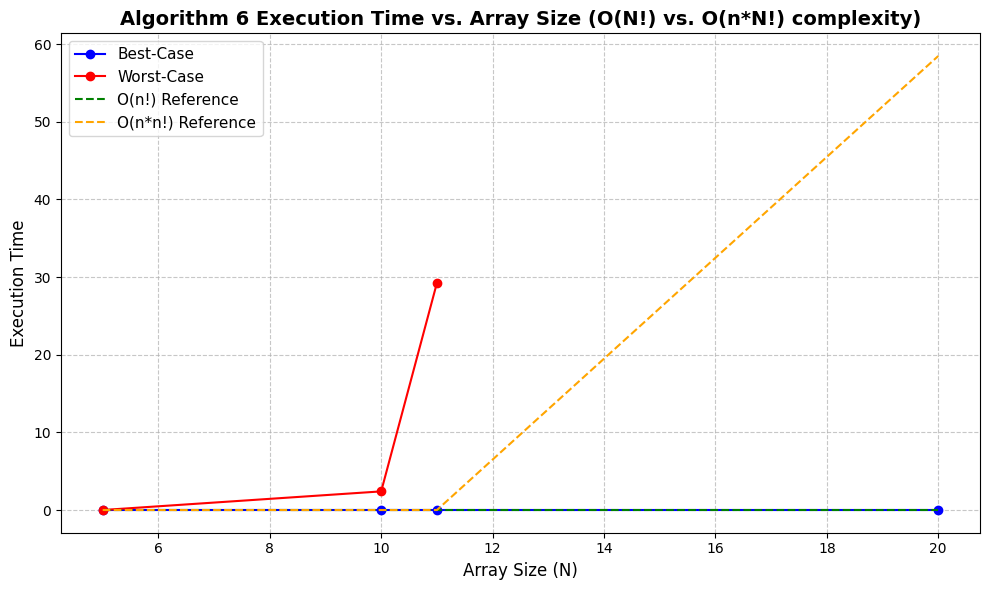

In [ ]:
"""
Anonymous Algorithm 6
Bruteforce Permutation "Sorting" Algorithm

Victor Morgan and Ahmed Abdallah
04/25/2026

This algorithm uses a brute-force backtracking approach to determine whether a
sorted permutation of the array exists. It recursively generates permutations by
swapping elements and exploring all possible arrangements. Once a full permutation
is formed, it checks whether the array is sorted. If a sorted configuration is found,
the algorithm terminates early. The best case occurs when the array is already sorted
or when a sorted permutation is encountered early. The worst case occurs when the
algorithm must explore nearly all N! permutations before finding a sorted arrangement,
resulting in extremely high computational cost.

A is the array, i is the beginning index, and N is the size of the array. As the
algorithm goes on i is incremented to compare and swap indices of the array, until
i reaches N where the array is checked to see if it is in order.

When running this algorithm, it times out when the input is reverse order of 15
elements or more.

Best Case: O(n!)
Worst Case: O(n*n!)
"""

import time
import matplotlib.pyplot as plt
import math

def Algorithm6(A, i, N):
  if i == N:
      for j in range(0, N-1):
        if A[j] > A[j+1]:
          return False
      return True
  if (Algorithm6(A, i+1, N)):
    return True
  for j in range(i+1, N):
    A[i], A[j] = A[j], A[i]
    if (Algorithm6(A, i+1, N)):
      return True
    A[i], A[j] = A[j], A[i]
  return False


if __name__ == "__main__":
  A = [2, 6, 7, 9, 18]
  C = [2, 3, 4, 5, 6, 7, 8, 9, 10, 18]
  D = [2, 4, 5, 7, 8, 9, 10, 11, 12, 14, 18]
  E = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
  F = [18, 9, 7, 6, 2]
  G = [18, 10, 9, 8, 7, 6, 5, 4, 3, 2]
  H = [18, 14, 12, 11, 10, 9, 8, 7, 5, 4, 2]
  I = [20, 19, 18, 17, 16, 15, 14, 13, 12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1]

  Best = [A, C, D, E]
  Worst = [F, G, H]
  Sizes = []
  Sizes2 = []
  Times1 = []
  Times2 = []

  for i in range(0, len(Best)):
    Sizes.append(len(Best[i]))

  for i in range(0, len(Worst)):
    Sizes2.append(len(Worst[i]))


  print("\nBest-Case, Already Sorted Arrays:\n")
  for i in range(0, len(Best)):
    array = Best[i]
    start = time.perf_counter()
    Algorithm6(array, 0, len(array))
    end = time.perf_counter()
    ExecuteTime = end - start
    Times1.append(ExecuteTime)
    print("Execution time on", len(array), "elements   = ", (ExecuteTime*100000), "\n")

  print("\nWorst-Case, Reverse Sorted Arrays:\n")
  for i in range(0, len(Worst)):
    array = Worst[i]
    start = time.perf_counter()
    Algorithm6(array, 0, len(array))
    end = time.perf_counter()
    ExecuteTime = end - start
    Times2.append(ExecuteTime)
    print("Execution time on", len(array), "elements   = ", (ExecuteTime*100000), "\n")

  cube_curve = [math.factorial(n) for n in Sizes]
  cube_curve2 = [n*math.factorial(n)/10 for n in Sizes]
  scale = max(Times1) / max(cube_curve)
  scale2 = max(Times2) / max(cube_curve)
  cube_curve_scaled = [x * scale for x in cube_curve]
  cube_curve_scaled2 = [x * scale2 for x in cube_curve2]

  print("\nGenerating plot...")
  plt.figure(figsize=(10, 6))

  # Draw the lines
  plt.plot(Sizes, Times1, marker='o', color='blue', label = 'Best-Case')
  plt.plot(Sizes2, Times2, marker='o', color='red', label = 'Worst-Case')
  plt.plot(Sizes, cube_curve_scaled, linestyle='--', color='green', label='O(n!) Reference')
  plt.plot(Sizes, cube_curve_scaled2, linestyle='--', color='orange', label='O(n*n!) Reference')

  # Formatting
  plt.title("Algorithm 6 Execution Time vs. Array Size (O(N!) vs. O(n*N!) complexity)", fontsize=14, fontweight='bold')
  plt.xlabel("Array Size (N)", fontsize=12)
  plt.ylabel("Execution Time", fontsize=12)
  plt.legend(fontsize=11)
  plt.grid(True, linestyle='--', alpha=0.7)
  plt.ticklabel_format(style='plain', axis='x')

  # Save the file and display it
  plt.tight_layout()
  plt.savefig("algorithm6_runtime_plot.png", dpi=300)
  plt.show()